1. Import Libraries

In [61]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import(
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import(
    EarlyStopping,
    ModelCheckpoint
)

2. Load DataSet

In [64]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3. Remove Unnecessary Column

In [65]:
df.drop("customerID", axis=1, inplace = True)

4. Handle TotalCharges

In [66]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isnull().sum()

np.int64(11)

5. Handle Missing Values

In [67]:
df.dropna(inplace = True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

6. Separate Features and Target

In [68]:
x = df.drop("Churn", axis = 1)
y = df["Churn"]

7. Encode Target

In [69]:
le = LabelEncoder()
y = le.fit_transform(y)


8. Indentify Features Types

In [70]:
categorical_columns = x.select_dtypes(
    include = "object"
).columns

numerical_columns = x.select_dtypes(
    include = np.number
).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_53521/1075560464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(


In [71]:
print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [72]:
print(numerical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


9. One-Hot Encode Features

In [73]:
x = pd.get_dummies(
    x,
    columns = categorical_columns,
    drop_first = True
)

10. Train-Test Split

In [75]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

11. Feature Scaling

In [76]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [77]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


12. Check Input Shape

In [78]:
x_train.shape

(5625, 30)

In [79]:
input_dim = x_train.shape[1]
print(input_dim)

30


13. Build ANN

In [80]:
model = Sequential([
    Dense(
        64,
        activation = "relu",
        input_shape = (input_dim,) 
    ),
    BatchNormalization(),
    Dropout(0.3),
    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),
    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14. Display Model Summary

In [81]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

15. Compile the Model

In [82]:
model.compile(
    optimizer = Adam(
        learning_rate = 0.001
    ),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

16. Configure Callbacks

In [83]:
#Early Stopping

early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

#Checkpoint

checkpoint = ModelCheckpoint(
    "../models/best_ann_model.keras",
    monitor = "val_loss",
    save_best_only = True
)

17. Train the Model

In [86]:
history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping, checkpoint],
    verbose = 1
)
# history = model.fit(
#     x_train,
#     y_train,
#     validation_split=0.2,
#     epochs=1,
#     batch_size=32,
#     verbose=1
# )

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6898 - loss: 0.6114 - val_accuracy: 0.7822 - val_loss: 0.4737
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7598 - loss: 0.5029 - val_accuracy: 0.7893 - val_loss: 0.4355
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7807 - loss: 0.4613 - val_accuracy: 0.7911 - val_loss: 0.4247
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7784 - loss: 0.4548 - val_accuracy: 0.7947 - val_loss: 0.4225
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7867 - loss: 0.4456 - val_accuracy: 0.7956 - val_loss: 0.4218
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7951 - loss: 0.4369 - val_accuracy: 0.7956 - val_loss: 0.4199
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7940 - loss: 0.4363 - val_accuracy: 0.7956 - val_loss: 0.4178
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7973 - loss: 0.4360 - val_accu

18. Plot Learning Curves

##### Loss

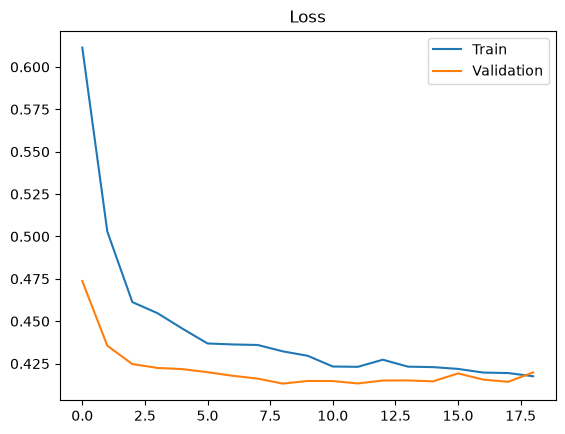

In [87]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()

##### Accuracy

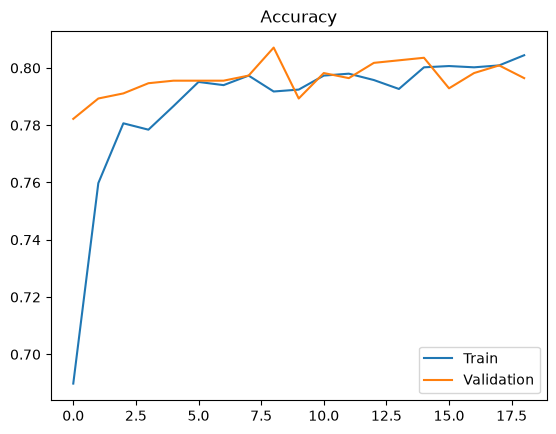

In [88]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

19. Initial Evaluation

In [89]:
loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose = 1
)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - accuracy: 0.7982 - loss: 0.4341


In [90]:
print(loss)
print(accuracy)

0.4340532720088959
0.7981520891189575


### Key Points

#### Objective
Designed, trained, and validated an Artificial Neural Network (ANN) for customer churn prediction using TensorFlow and Keras.

#### Tasks Performed
- Built a Sequential ANN architecture with two hidden layers.
- Used ReLU activation for hidden layers and Sigmoid activation for the output layer.
- Added Batch Normalization layers to stabilize training.
- Applied Dropout to reduce overfitting.
- Compiled the model using the Adam optimizer and Binary Crossentropy loss.
- Configured EarlyStopping and ModelCheckpoint callbacks.
- Trained the ANN using a validation split.
- Monitored learning using training and validation loss/accuracy curves.
- Evaluated the trained model on the test dataset.

#### Results
- Training converged smoothly without instability.
- EarlyStopping terminated training after approximately 19 epochs, preventing unnecessary training.
- Training and validation curves remained closely aligned, indicating good generalization.
- No significant signs of overfitting or underfitting were observed.

#### Key Learnings
- Batch Normalization improves training stability and convergence.
- Dropout effectively reduces overfitting.
- EarlyStopping saves computation and helps preserve the best-performing model.
- Monitoring learning curves is essential for diagnosing model performance.

#### Outcome
A well-generalized Artificial Neural Network has been successfully trained for customer churn prediction. The model demonstrates stable learning behavior and is ready for detailed performance evaluation using Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix in the next phase.